# 02 Data Understanding

This notebook explores the raw source tables created for the AgriCredit Resilience project.

The purpose of this notebook is to understand the structure, quality, and basic patterns of the raw data before creating the final Analytical Base Table (ABT).

The main tasks are:

1. Load raw CSV files
2. Check table shapes and columns
3. Inspect sample rows
4. Check data types
5. Identify missing values
6. Check duplicate records
7. Examine categorical values
8. View numeric summaries
9. Create simple visualizations
10. Summarize data quality issues

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [10]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

RAW_DATA_DIR

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/data/raw')

In [11]:
raw_files = {
    "households": "households_raw.csv",
    "agriculture": "agriculture_raw.csv",
    "coping": "coping_raw.csv",
    "market_prices": "market_prices_raw.csv",
    "meb_values": "meb_values_raw.csv",
    "assistance_coverage": "assistance_coverage_raw.csv",
}

data = {}

for name, filename in raw_files.items():
    file_path = RAW_DATA_DIR / filename
    data[name] = pd.read_csv(file_path)

print("Raw data loaded successfully.")

Raw data loaded successfully.


In [12]:
shape_report = []

for name, df in data.items():
    shape_report.append({
        "table_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
    })

shape_report_df = pd.DataFrame(shape_report)
shape_report_df

,table_name,rows,columns
0,households,1500,13
1,agriculture,1500,7
2,coping,1500,7
3,market_prices,14,6
4,meb_values,14,3
5,assistance_coverage,14,6


### Observation

The raw dataset contains six source tables. Three tables are household-level tables with 1,500 rows each: `households`, `agriculture`, and `coping`. These tables can later be merged using `household_id`.

The other three tables are state/region-level tables with 14 rows each: `market_prices`, `meb_values`, and `assistance_coverage`. These tables can later be merged into the household-level ABT using `state_region`.

This confirms that the final ABT should use one row per household.

In [13]:
for name, df in data.items():
    print("=" * 80)
    print(f"Table: {name}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    
    for col in df.columns:
        print(f"- {col}")

Table: households
Shape: (1500, 13)
Columns:
- household_id
- state_region
- township
- household_size
- monthly_income
- has_debt
- total_debt
- monthly_debt_repayment
- savings_duration_weeks
- market_access
- female_headed_household
- disability_present
- displacement_status
Table: agriculture
Shape: (1500, 7)
Columns:
- household_id
- is_farming_household
- main_crop
- farm_size_acres
- irrigation_access
- fertilizer_cost
- crop_damage_recent
Table: coping
Shape: (1500, 7)
Columns:
- household_id
- less_preferred_food_days
- borrowed_food_days
- reduced_meals_days
- reduced_portion_days
- adults_reduced_for_children_days
- basic_needs_met
Table: market_prices
Shape: (14, 6)
Columns:
- state_region
- month
- basic_food_basket_change_1y
- rice_price_change_1y
- fuel_price_change_1y
- market_disruption_level
Table: meb_values
Shape: (14, 3)
Columns:
- state_region
- mpca_per_person
- cash_food_assistance_per_person
Table: assistance_coverage
Shape: (14, 6)
Columns:
- state_region
- pe

## Sample Rows

The following cells show the first few rows from each raw table. This helps us understand the format and structure of the data.

In [15]:
data["households"].head()

,household_id,state_region,township,household_size,monthly_income,has_debt,total_debt,monthly_debt_repayment,savings_duration_weeks,market_access,female_headed_household,disability_present,displacement_status
0,HH00001,Magway,Magway,6,610149.0,yes,851624,150329,1,Yes,No,No,IDP
1,HH00002,Ayeyarwady,Pathein,8,284061.0,Yes,801819,95454,4,No,No,No,Resident
2,HH00003,Shan North,Lashio,4,50000.0,No,0,0,2,Unknown,No,No,Resident
3,HH00004,Kayin,Hpa-An,4,101947.0,Yes,667989,60245,2,Yes,No,No,Resident
4,HH00005,Kayin,Myawaddy,6,675893.0,Yes,593253,81094,1,N,No,No,Returnee


In [16]:
data["agriculture"].head()

,household_id,is_farming_household,main_crop,farm_size_acres,irrigation_access,fertilizer_cost,crop_damage_recent
0,HH00001,Yes,Rice,3.80,No,88356.0,No
1,HH00002,Yes,Rice,2.90,No,236635.0,No
2,HH00003,Yes,Rice,0.63,No,185682.0,Yes
3,HH00004,No,NaN,0.00,No,0.0,No
4,HH00005,No,NaN,0.00,No,0.0,No


In [17]:
data["coping"].head()

,household_id,less_preferred_food_days,borrowed_food_days,reduced_meals_days,reduced_portion_days,adults_reduced_for_children_days,basic_needs_met
0,HH00001,0.0,0.0,0.0,2.0,0.0,Yes mostly
1,HH00002,6.0,0.0,2.0,6.0,1.0,Yes mostly
2,HH00003,5.0,2.0,1.0,3.0,3.0,Only some
3,HH00004,1.0,1.0,2.0,1.0,3.0,Yes mostly
4,HH00005,7.0,NaN,5.0,3.0,1.0,Only some


In [18]:
data["market_prices"].head()

,state_region,month,basic_food_basket_change_1y,rice_price_change_1y,fuel_price_change_1y,market_disruption_level
0,Sagaing,2025-04,34.4,10.9,34.3,Medium
1,Magway,2025-04,61.4,11.4,8.6,Medium
2,Mandalay,2025-04,11.3,9.2,35.3,Low
3,Chin,2025-04,39.8,12.5,25.0,Medium
4,Kachin,2025-04,15.2,18.4,1.1,Low


In [19]:
data["meb_values"].head()

,state_region,mpca_per_person,cash_food_assistance_per_person
0,Bago,55000,35000
1,Chin,95000,65000
2,Kachin,65000,50000
3,Kayah,80000,55000
4,Kayin,65000,40000


In [20]:
data["assistance_coverage"].head()

,state_region,people_targeted,people_reached,coverage_rate,response_gap,number_of_partners_active
0,Sagaing,178672,122516,0.686,56156,12
1,Magway,24770,9411,0.380,15359,21
2,Mandalay,147038,87058,0.592,59980,26
3,Chin,104011,39085,0.376,64926,10
4,Kachin,59479,21163,0.356,38316,20


## Data Type Report

This section checks the data type of each column. Data types are important because machine learning models require clean numeric and categorical features.

In [21]:
dtype_report = []

for table_name, df in data.items():
    for column in df.columns:
        dtype_report.append({
            "table_name": table_name,
            "column": column,
            "dtype": str(df[column].dtype),
        })

dtype_report_df = pd.DataFrame(dtype_report)
dtype_report_df

,table_name,column,dtype
0,households,household_id,str
1,households,state_region,str
2,households,township,str
3,households,household_size,int64
4,households,monthly_income,str
5,households,has_debt,str
6,households,total_debt,int64
7,households,monthly_debt_repayment,int64
8,households,savings_duration_weeks,int64
9,households,market_access,str


## Missing Values Report

This section checks how many missing values exist in each column. Missing values are one of the most common data quality issues in predictive analytics projects.

In [22]:
missing_report = []

for table_name, df in data.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        missing_percent = (missing_count / len(df)) * 100
        
        missing_report.append({
            "table_name": table_name,
            "column": column,
            "missing_count": missing_count,
            "missing_percent": round(missing_percent, 2),
        })

missing_report_df = pd.DataFrame(missing_report)
missing_report_df.sort_values(by="missing_count", ascending=False)

,table_name,column,missing_count,missing_percent
15,agriculture,main_crop,358,23.87
4,households,monthly_income,60,4.00
18,agriculture,fertilizer_cost,45,3.00
21,coping,less_preferred_food_days,22,1.47
23,coping,reduced_meals_days,22,1.47
24,coping,reduced_portion_days,22,1.47
25,coping,adults_reduced_for_children_days,22,1.47
22,coping,borrowed_food_days,22,1.47
35,meb_values,cash_food_assistance_per_person,0,0.00
34,meb_values,mpca_per_person,0,0.00


In [23]:
missing_report_df[missing_report_df["missing_count"] > 0].sort_values(
    by="missing_count",
    ascending=False
)

,table_name,column,missing_count,missing_percent
15,agriculture,main_crop,358,23.87
4,households,monthly_income,60,4.00
18,agriculture,fertilizer_cost,45,3.00
21,coping,less_preferred_food_days,22,1.47
22,coping,borrowed_food_days,22,1.47
23,coping,reduced_meals_days,22,1.47
24,coping,reduced_portion_days,22,1.47
25,coping,adults_reduced_for_children_days,22,1.47


### Observation

The missing values report shows several data quality issues in the raw data. The `main_crop` column has the highest missing rate because non-farming households do not have a crop type. The `monthly_income` column has 60 missing values, representing 4% of household records. The `fertilizer_cost` column has 45 missing values, representing 3% of agriculture records. Several coping strategy columns also contain missing values.

These issues confirm that data preparation is required before building the final ABT. Missing numeric values will need to be handled, and missing crop values should be interpreted carefully because they may represent non-farming households rather than simple data errors.

## Duplicate Records Check

This section checks whether any table contains duplicate rows or duplicate household IDs.

In [24]:
duplicate_report = []

for table_name, df in data.items():
    duplicate_rows = df.duplicated().sum()
    
    duplicate_report.append({
        "table_name": table_name,
        "duplicate_rows": duplicate_rows,
    })

pd.DataFrame(duplicate_report)

,table_name,duplicate_rows
0,households,0
1,agriculture,0
2,coping,0
3,market_prices,0
4,meb_values,0
5,assistance_coverage,0


In [25]:
id_checks = []

for table_name in ["households", "agriculture", "coping"]:
    df = data[table_name]
    
    id_checks.append({
        "table_name": table_name,
        "unique_household_ids": df["household_id"].nunique(),
        "total_rows": len(df),
        "duplicate_household_ids": df["household_id"].duplicated().sum(),
    })

pd.DataFrame(id_checks)

,table_name,unique_household_ids,total_rows,duplicate_household_ids
0,households,1500,1500,0
1,agriculture,1500,1500,0
2,coping,1500,1500,0


### Observation

The duplicate check shows that there are no fully duplicated rows in any of the six raw tables. The household-level tables also contain 1,500 unique `household_id` values, with no duplicate household IDs.

This is important because the final ABT will use one row per household. Since `household_id` is unique in the `households`, `agriculture`, and `coping` tables, these tables can be safely merged later without creating duplicated household records.

## Categorical Value Checks

This section examines unique values in important categorical columns. This helps identify inconsistent values such as Yes, yes, Y, No, no, and N.

In [26]:
categorical_checks = {
    "households": [
        "state_region",
        "has_debt",
        "market_access",
        "female_headed_household",
        "disability_present",
        "displacement_status",
    ],
    "agriculture": [
        "is_farming_household",
        "main_crop",
        "irrigation_access",
        "crop_damage_recent",
    ],
    "coping": [
        "basic_needs_met",
    ],
    "market_prices": [
        "state_region",
        "market_disruption_level",
    ],
}

In [27]:
for table_name, columns in categorical_checks.items():
    print("=" * 80)
    print(f"Table: {table_name}")
    
    for column in columns:
        print("\n" + "-" * 40)
        print(f"Column: {column}")
        print(data[table_name][column].value_counts(dropna=False))

Table: households

----------------------------------------
Column: state_region
state_region
Kayin            126
Ayeyarwady       121
Magway           120
Bago             120
Rakhine          116
Tanintharyi      110
Kachin           104
Shan South       101
Sagaing           98
Chin              97
Shan North        96
Mon               94
Mandalay          94
Kayah             94
sagaing            3
Northern Shan      2
Magwe              2
Southern Shan      2
Name: count, dtype: int64

----------------------------------------
Column: has_debt
has_debt
Yes    514
Y      307
No     260
yes    187
N      137
no      95
Name: count, dtype: int64

----------------------------------------
Column: market_access
market_access
Yes        765
No         373
Y          162
N          119
Unknown     81
Name: count, dtype: int64

----------------------------------------
Column: female_headed_household
female_headed_household
No     1110
Yes     390
Name: count, dtype: int64

--------------

### Observation

The categorical value check shows several important data quality issues. Some state/region names are inconsistent, such as `sagaing`, `Magwe`, `Southern Shan`, and `Northern Shan`. These values need to be standardized before merging household-level data with state-level data.

Several Yes/No columns also contain inconsistent formats, such as `Yes`, `yes`, `Y`, `No`, `no`, and `N`. These values should be converted into consistent binary values during data preparation.

The `market_access` column also contains `Unknown`, which needs to be handled carefully. The `main_crop` column contains missing values, but these missing values match non-farming households, so they should be interpreted as `None` rather than simple data entry errors.

The `basic_needs_met` column has ordered categories: `Yes fully`, `Yes mostly`, `Only some`, and `No`. This column can later be converted into a numeric score for feature engineering.

## Numeric Summary Statistics

This section summarizes numeric columns using count, mean, standard deviation, minimum, maximum, and quartiles.

In [28]:
for table_name, df in data.items():
    print("=" * 80)
    print(f"Table: {table_name}")
    display(df.describe())

Table: households


,household_size,total_debt,monthly_debt_repayment,savings_duration_weeks
count,1500.000000,1.500000e+03,1500.000000,1500.000000
mean,4.750667,4.436969e+05,50123.493333,2.782000
std,1.897428,4.156473e+05,49594.984923,3.089688
min,1.000000,0.000000e+00,0.000000,0.000000
25%,3.000000,0.000000e+00,0.000000,1.000000
50%,5.000000,4.450935e+05,44480.000000,2.000000
75%,6.000000,7.468532e+05,86217.750000,3.000000
max,9.000000,1.802849e+06,219367.000000,12.000000


Table: agriculture


,farm_size_acres,fertilizer_cost
count,1500.000000,1455.000000
mean,2.335113,117133.126460
std,1.935516,90805.668806
min,0.000000,0.000000
25%,0.200000,3186.500000
50%,2.330000,123631.000000
75%,3.880000,186187.500000
max,7.750000,371043.000000


Table: coping


...

,basic_food_basket_change_1y,rice_price_change_1y,fuel_price_change_1y
count,14.000000,14.000000,14.000000
mean,27.157143,14.328571,25.592857
std,16.543217,3.615018,19.242440
min,1.500000,9.200000,1.100000
25%,12.275000,11.250000,10.500000
50%,29.550000,12.700000,23.100000
75%,37.325000,17.575000,35.050000
max,61.400000,19.700000,68.500000


Table: meb_values


,mpca_per_person,cash_food_assistance_per_person
count,14.000000,14.000000
mean,61428.571429,39642.857143
std,11998.168358,11000.749225
min,55000.000000,30000.000000
25%,55000.000000,31250.000000
50%,55000.000000,35000.000000
75%,63750.000000,47500.000000
max,95000.000000,65000.000000


Table: assistance_coverage


,people_targeted,people_reached,coverage_rate,response_gap,number_of_partners_active
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,111870.500000,51079.285714,0.455857,60791.214286,17.285714
std,63346.647122,33946.598872,0.145970,40056.965174,6.231787
min,23931.000000,9411.000000,0.256000,9415.000000,6.000000
25%,65637.500000,23041.000000,0.361750,34076.000000,12.500000
50%,107975.500000,41290.500000,0.383500,56197.000000,18.500000
75%,143566.250000,80683.000000,0.587500,78680.250000,21.000000
max,228768.000000,122516.000000,0.706000,146550.000000,28.000000


### Observation

The numeric summary shows that the raw numerical values are mostly within reasonable ranges. Household size ranges from 1 to 9 people, and savings duration ranges from 0 to 12 weeks. Debt-related columns contain many zero values because not all households have debt.

The agriculture table includes zero farm sizes for non-farming households. Fertilizer cost has fewer non-missing records than total rows, which confirms the missing value issue found earlier.

The coping strategy columns contain values within expected day ranges, but each column has fewer than 1,500 valid records because of missing values. These columns can later be used to engineer a coping strategy score.

The market price table shows variation in food basket, rice, and fuel price changes across states/regions. The MEB values and assistance coverage tables provide state-level contextual information that can be merged into the household-level ABT.

## Initial Data Quality Findings

Based on the exploration above, the raw data contains several realistic data quality issues:

1. `monthly_income` contains mixed formats, including numeric values and text values with "MMK".
2. `monthly_income` contains missing values.
3. `fertilizer_cost` contains missing values.
4. Several Yes/No columns contain inconsistent values such as Yes, yes, Y, No, no, and N.
5. `market_access` contains Unknown values.
6. `state_region` contains inconsistent spellings such as sagaing, Magwe, Southern Shan, and Northern Shan.
7. Coping strategy day columns contain missing values.
8. Household-level tables contain 1,500 rows, while state-level tables contain 14 rows.
9. The future ABT should use one row per household.
10. State-level tables must be merged into the household-level ABT using `state_region`.

## Data Visualizations

This section creates simple visualizations to better understand the raw data. The goal is to observe distributions, category counts, and state-level differences before data preparation.

In [29]:
households_viz = data["households"].copy()

households_viz["monthly_income_clean"] = (
    households_viz["monthly_income"]
    .astype("string")
    .str.replace("MMK", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

households_viz["monthly_income_clean"] = pd.to_numeric(
    households_viz["monthly_income_clean"],
    errors="coerce"
)

households_viz[["monthly_income", "monthly_income_clean"]].head(10)

,monthly_income,monthly_income_clean
0,610149.0,610149.0
1,284061.0,284061.0
2,50000.0,50000.0
3,101947.0,101947.0
4,675893.0,675893.0
5,347774.0,347774.0
6,284870.0,284870.0
7,715679.0,715679.0
8,647729.0,647729.0
9,424401.0,424401.0


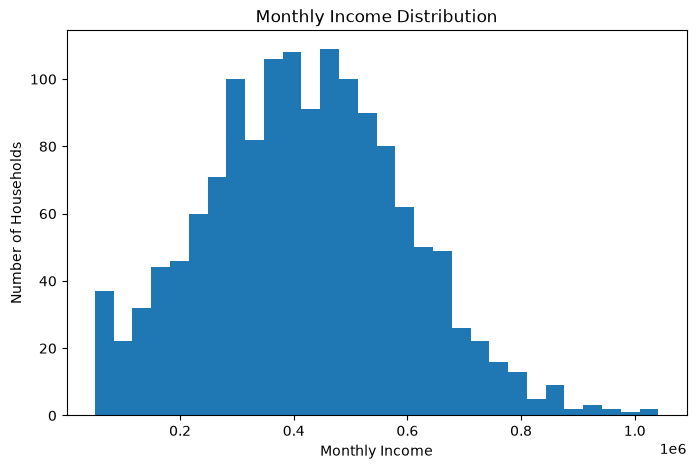

In [30]:
plt.figure(figsize=(8, 5))

households_viz["monthly_income_clean"].dropna().plot(kind="hist", bins=30)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Households")
plt.show()

### Observation

The monthly income distribution shows how household income is spread across the sample. This helps identify whether most households are concentrated around lower, middle, or higher income levels. Missing income values were excluded only for this visualization.

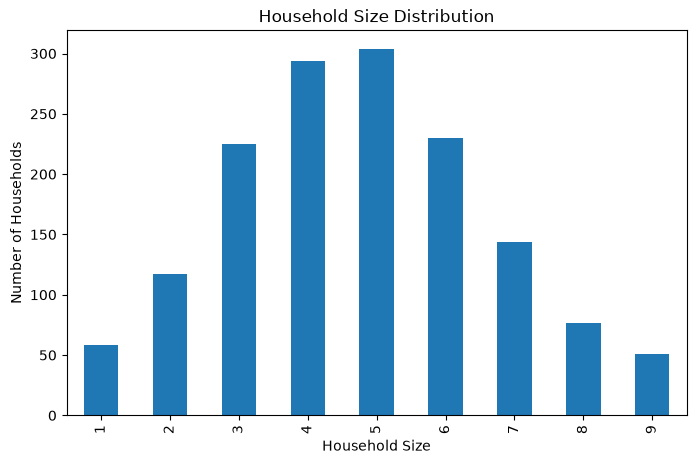

In [31]:
plt.figure(figsize=(8, 5))

data["households"]["household_size"].value_counts().sort_index().plot(kind="bar")

plt.title("Household Size Distribution")
plt.xlabel("Household Size")
plt.ylabel("Number of Households")
plt.show()

### Observation

The household size distribution shows that most households are medium-sized, while very small and very large households are less common. Household size will be important later because it affects the household's minimum expenditure requirement.

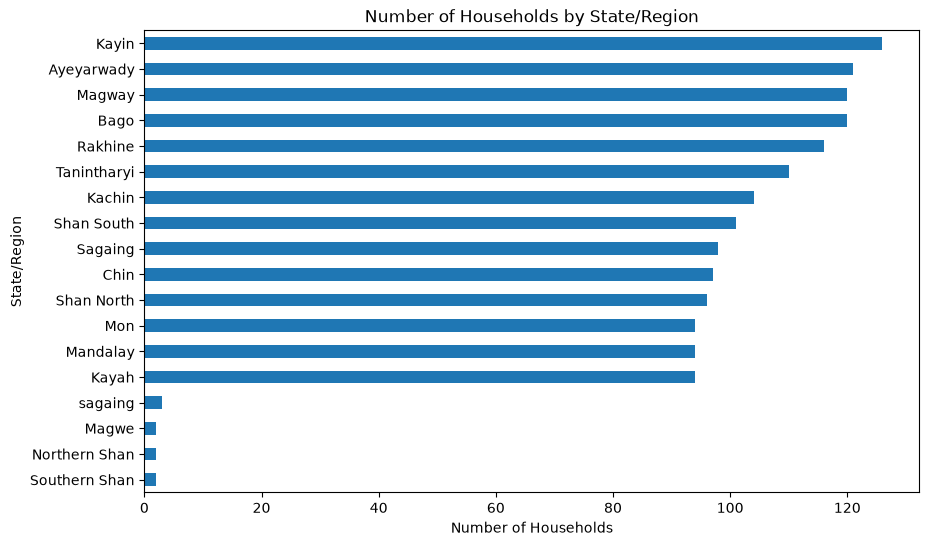

In [32]:
plt.figure(figsize=(10, 6))

data["households"]["state_region"].value_counts().sort_values().plot(kind="barh")

plt.title("Number of Households by State/Region")
plt.xlabel("Number of Households")
plt.ylabel("State/Region")
plt.show()

### Observation

The state/region distribution shows the number of household records in each location. It also reveals inconsistent location names such as `sagaing`, `Magwe`, `Southern Shan`, and `Northern Shan`, which need to be standardized before merging tables.

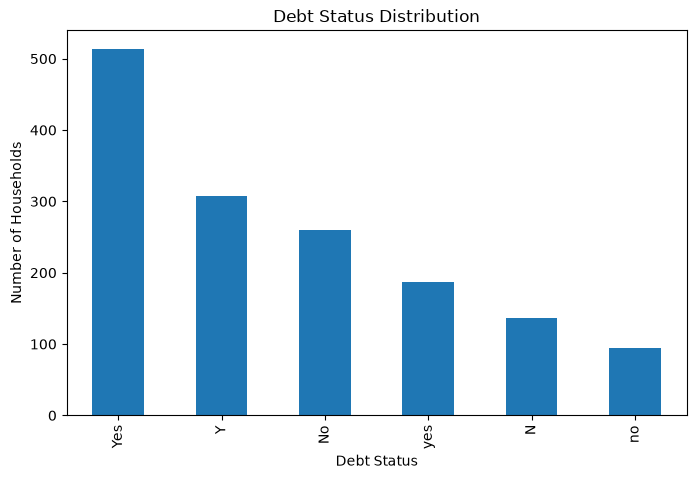

In [33]:
plt.figure(figsize=(8, 5))

data["households"]["has_debt"].value_counts().plot(kind="bar")

plt.title("Debt Status Distribution")
plt.xlabel("Debt Status")
plt.ylabel("Number of Households")
plt.show()

### Observation

The debt status distribution shows that the raw data contains inconsistent Yes/No values, such as `Yes`, `yes`, `Y`, `No`, `no`, and `N`. These values should be standardized during data preparation.

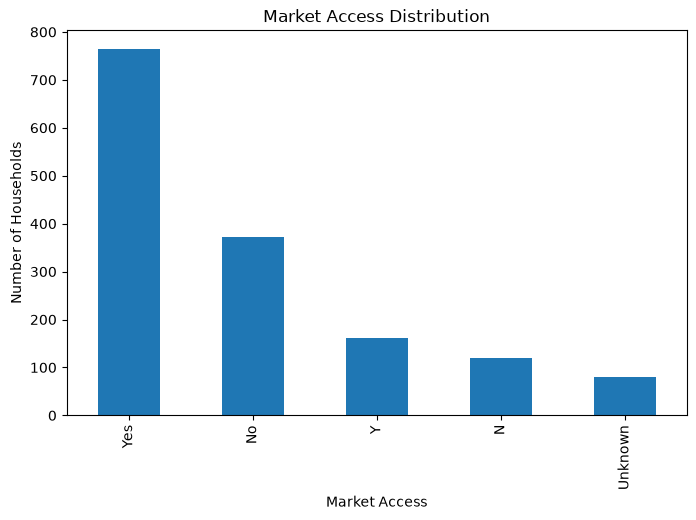

In [34]:
plt.figure(figsize=(8, 5))

data["households"]["market_access"].value_counts().plot(kind="bar")

plt.title("Market Access Distribution")
plt.xlabel("Market Access")
plt.ylabel("Number of Households")
plt.show()

### Observation

The market access distribution shows that most households report access to markets, but some report no access or unknown access. The `Unknown` category needs to be handled carefully during data preparation because market access is an important vulnerability feature.

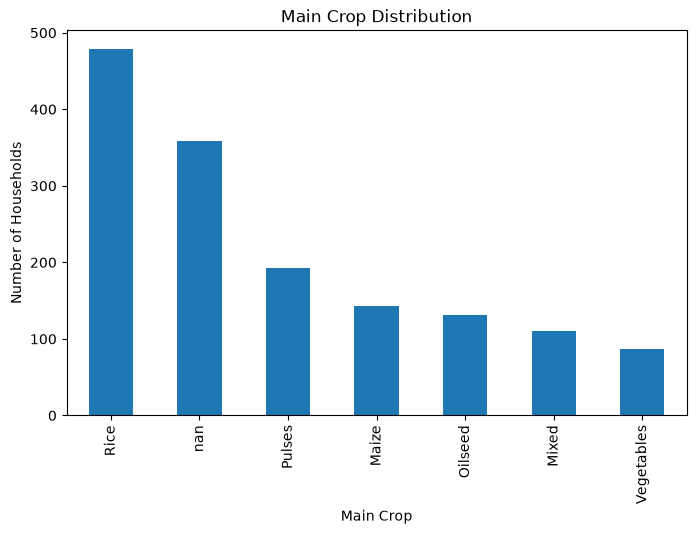

In [35]:
plt.figure(figsize=(8, 5))

data["agriculture"]["main_crop"].value_counts(dropna=False).plot(kind="bar")

plt.title("Main Crop Distribution")
plt.xlabel("Main Crop")
plt.ylabel("Number of Households")
plt.show()

### Observation

The main crop distribution shows that rice is the most common crop in the raw data. The missing values in `main_crop` mostly represent non-farming households, so they should be treated as `None` rather than as ordinary missing data.

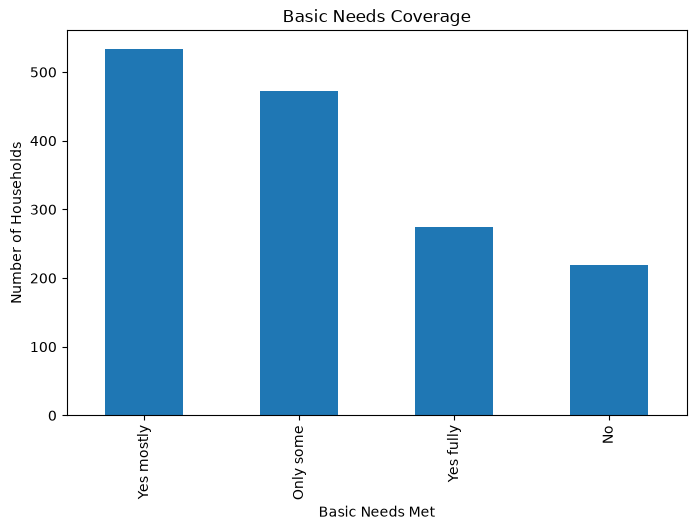

In [36]:
plt.figure(figsize=(8, 5))

data["coping"]["basic_needs_met"].value_counts().plot(kind="bar")

plt.title("Basic Needs Coverage")
plt.xlabel("Basic Needs Met")
plt.ylabel("Number of Households")
plt.show()

### Observation

The basic needs coverage chart shows different levels of household need. The categories have a natural order from `Yes fully` to `No`, so this feature can later be transformed into a numeric basic needs score.

<Figure size 1000x600 with 0 Axes>

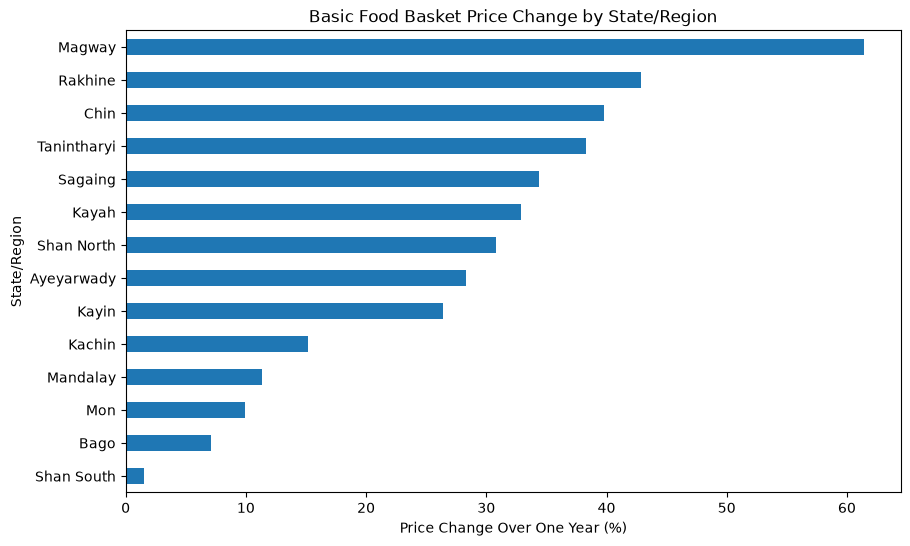

In [37]:
plt.figure(figsize=(10, 6))

data["market_prices"].sort_values("basic_food_basket_change_1y").plot(
    x="state_region",
    y="basic_food_basket_change_1y",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

plt.title("Basic Food Basket Price Change by State/Region")
plt.xlabel("Price Change Over One Year (%)")
plt.ylabel("State/Region")
plt.show()

### Observation

The food basket price change chart shows that market pressure differs by state/region. This state-level information can later be merged into the household-level ABT to represent local market conditions.

<Figure size 1000x600 with 0 Axes>

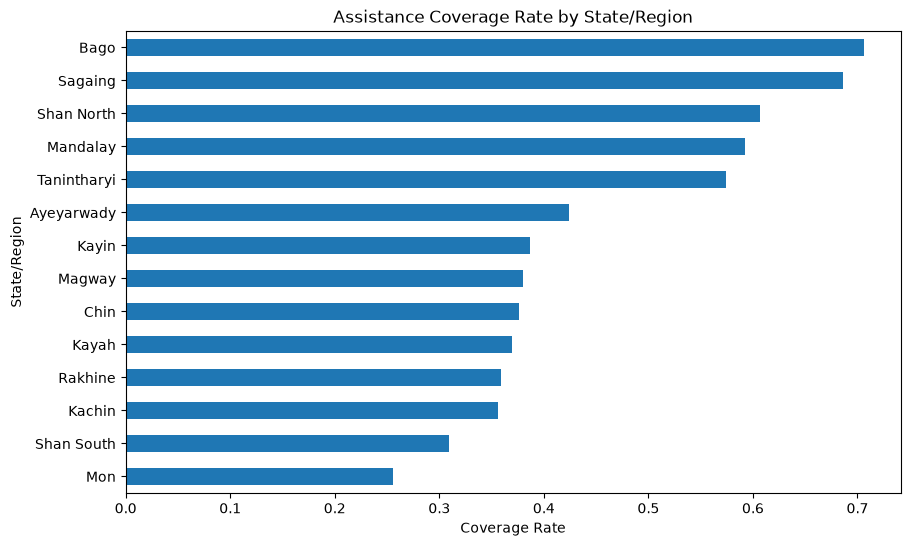

In [38]:
plt.figure(figsize=(10, 6))

data["assistance_coverage"].sort_values("coverage_rate").plot(
    x="state_region",
    y="coverage_rate",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

plt.title("Assistance Coverage Rate by State/Region")
plt.xlabel("Coverage Rate")
plt.ylabel("State/Region")
plt.show()

### Observation

The assistance coverage chart shows differences in humanitarian support coverage across states/regions. Lower coverage may indicate a larger response gap, which can be useful contextual information in the final ABT.

### Visualization Summary

The visualizations support the earlier data quality findings. The income distribution shows a realistic spread of household income, while household size is mostly concentrated around medium-sized households.

The state/region chart reveals inconsistent location names such as `sagaing`, `Magwe`, `Northern Shan`, and `Southern Shan`. These must be standardized before merging state-level tables into the household-level ABT.

The debt status and market access charts also show inconsistent category formats. Values such as `Yes`, `yes`, and `Y` should be converted into one consistent value. Similarly, `No`, `no`, and `N` should be standardized.

The main crop chart shows missing crop values. These missing values are likely linked to non-farming households and should be converted to `None` during data preparation.

The food basket price and assistance coverage charts show that market pressure and assistance coverage differ across states/regions. These state-level differences can provide useful contextual features in the final ABT.

## Data Understanding Summary

The raw data contains six source tables. Three tables are household-level tables with 1,500 rows each, and three tables are state/region-level tables with 14 rows each.

The data quality checks found several issues that must be handled during data preparation:

1. `monthly_income` contains mixed formats, including numeric values and values with `MMK`.
2. `monthly_income`, `fertilizer_cost`, and coping strategy columns contain missing values.
3. Yes/No columns use inconsistent formats such as `Yes`, `yes`, `Y`, `No`, `no`, and `N`.
4. `state_region` contains inconsistent names such as `sagaing`, `Magwe`, `Southern Shan`, and `Northern Shan`.
5. `main_crop` contains missing values, but these mostly represent non-farming households.
6. The household-level tables can be merged using `household_id`.
7. The state-level tables can be merged into the household-level ABT using `state_region`.

The next step is data preparation, where these issues will be cleaned and the final Analytical Base Table will be created.